In [2]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")

# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\_aromatic_2025_2717_CHNS.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
1339,5-Phenyl-thiazolidine,C9H11NS,165,107326-19-2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,C1NCC(S1)c2ccccc2,CHNS
3277,"2-Amino-6-n-butyl-3-cyano-4,5,6,7-tetrahydroth...",C12H17N3S,235,42159-78-4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCN1CCc2c(C1)sc(N)c2C#N,CHNS
3302,"Pyrimidine, 1,4,5,6-tetrahydro-1-methyl-2-[2-(...",C11H14N2S,206,5686-02-2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CN1CCCN=C1C=Cc2sccc2,CHNS
3332,"2,4-Diamino-5,6,7,8-tetrahydro-7-methylpyrido[...",C10H13N5S,235,42159-88-6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CN1CCc2c(C1)sc3nc(N)nc(N)c23,CHNS
3704,"1,3,5-Triazin-2-amine, 4-azido-N-(1-methylethy...",C7H11N7S,225,4658-28-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CSc1nc(NC(C)C)nc(N=[N+]=[N-])n1,CHNS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181510,"Acetonitrile, (5,7-dimethyl-[1,2,4]triazolo[1,...",C9H9N5S,219,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Cc1cc(C)n2nc(SCC#N)nc2n1,CHNS
181526,"[1,2,4]Triazolo[1,5-a]pyrimidine, 2-ethylsulfa...",C9H12N4S,208,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCSc1nn2c(C)cc(C)nc2n1,CHNS
181542,"7H-[1,2,4]Triazolo[4,3-b][1,2,4]triazole, 3-me...",C8H8N6S,220,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CSc1nnc2n(cnn12)n3cccc3,CHNS
181773,"3-(n-Propylamino)-2,1-benzisothiazole",C10H12N2S,192,708-42-9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCNc1snc2ccccc12,CHNS


In [ ]:
import deepchem as dc
import selfies as sf
import pandas as pd
X = ms.iloc[:, 4:604]     # spectra
y = ms.iloc[:, 605]       # smiles

se = []
dr = []  # list of indices to drop
c = 0

# Check all SMILES and filter out invalid/unsupported ones
for i in y:
    try:
        selfies_str = sf.encoder(i)
        se.append(selfies_str)
        if '.' in selfies_str:  # check for multi-molecule SMILES
            dr.append(c)
    except Exception as e:
        # Add to drop list if encoding fails (chemically invalid SMILES)
        dr.append(c)
    c += 1

# Drop problematic rows from original DataFrame
ms_cleaned = ms.drop(index=ms.index[dr]).reset_index(drop=True)

# Extract cleaned spectra and SMILES
X_clean = ms_cleaned.iloc[:, 4:604].to_numpy()
y_clean = ms_cleaned.iloc[:, 605].to_numpy()

# Create DeepChem dataset
ds = dc.data.DiskDataset.from_numpy(X_clean, y_clean)
ds

<DiskDataset X.shape: (np.int64(2717), np.int64(600)), y.shape: (np.int64(2717),), w.shape: (np.int64(2717),), task_names: [0]>

In [5]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[#N]': 3,
 '[/-Ring1]': 4,
 '[/C]': 5,
 '[/N]': 6,
 '[=Branch1]': 7,
 '[=Branch2]': 8,
 '[=CH0]': 9,
 '[=CH1]': 10,
 '[=C]': 11,
 '[=N+1]': 12,
 '[=N-1]': 13,
 '[=N]': 14,
 '[=Ring1]': 15,
 '[=Ring2]': 16,
 '[=SH0]': 17,
 '[=S]': 18,
 '[Branch1]': 19,
 '[Branch2]': 20,
 '[C@@H1]': 21,
 '[C@H1]': 22,
 '[CH0]': 23,
 '[CH1]': 24,
 '[CH2]': 25,
 '[C]': 26,
 '[N-1]': 27,
 '[NH1]': 28,
 '[N]': 29,
 '[O]': 30,
 '[P]': 31,
 '[Ring1]': 32,
 '[Ring2]': 33,
 '[S]': 34,
 '[\\-Ring1]': 35,
 '[\\C]': 36,
 '[\\N]': 37,
 '[nop]': 38}

In [6]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [7]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 2392
📦 Validation set size: 0
📦 Test set size: 325


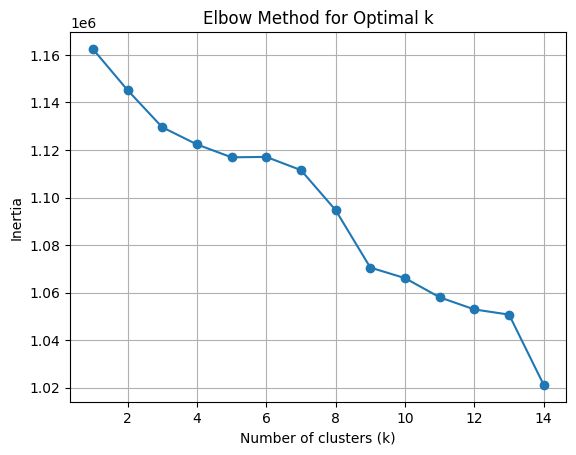

🔍 Elbow point detected at k = 3


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [9]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=3,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=3)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  m

In [10]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(3):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (283, 600)
Cluster 1 shape: (1785, 600)
Cluster 2 shape: (324, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  m

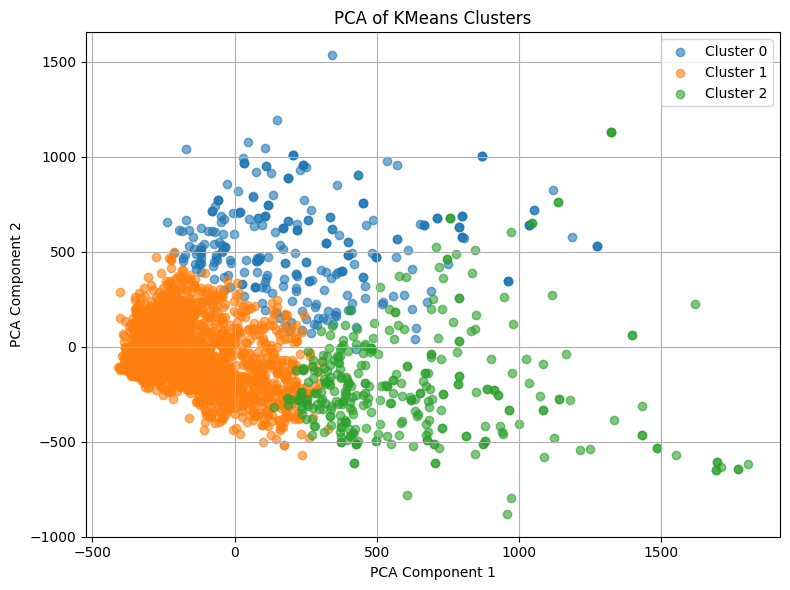

In [11]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=3)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [12]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [13]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")





✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indice

Cluster 0: size = 38, shape = (38, 600)
Cluster 1: size = 246, shape = (246, 600)
Cluster 2: size = 41, shape = (41, 600)


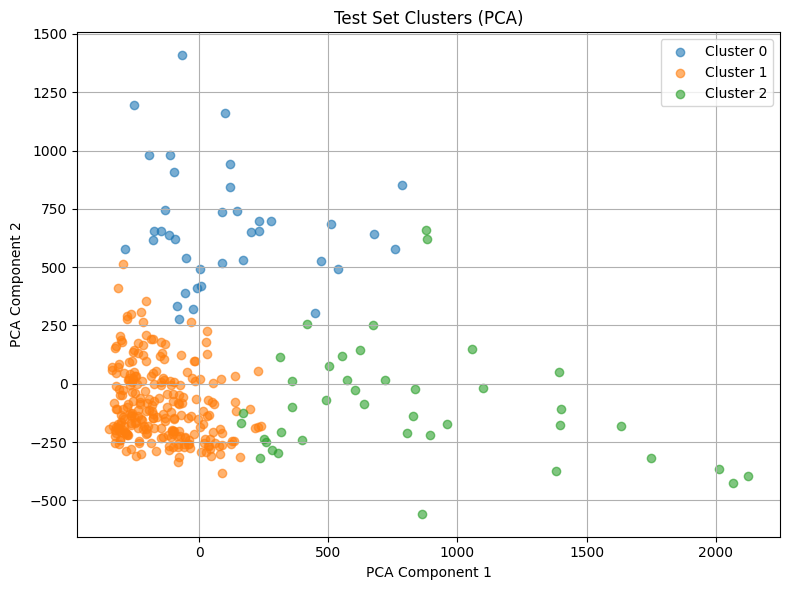

In [14]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(3):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 0.917548
Epoch 2/100 - Loss: 0.071190
Epoch 3/100 - Loss: 0.048759
Epoch 4/100 - Loss: 0.039927
Epoch 5/100 - Loss: 0.037382
Epoch 6/100 - Loss: 0.035402
Epoch 7/100 - Loss: 0.033285
Epoch 8/100 - Loss: 0.031633
Epoch 9/100 - Loss: 0.030062
Epoch 10/100 - Loss: 0.028496
Epoch 11/100 - Loss: 0.027138
Epoch 12/100 - Loss: 0.025839
Epoch 13/100 - Loss: 0.024385
Epoch 14/100 - Loss: 0.022969
Epoch 15/100 - Loss: 0.021516
Epoch 16/100 - Loss: 0.020177
Epoch 17/100 - Loss: 0.018687
Epoch 18/100 - Loss: 0.017290
Epoch 19/100 - Loss: 0.015897
Epoch 20/100 - Loss: 0.014698
Epoch 21/100 - Loss: 0.013314
Epoch 22/100 - Loss: 0.012082
Epoch 23/100 - Loss: 0.011203
Epoch 24/100 - Loss: 0.010056
Epoch 25/100 - Loss: 0.009157
Epoch 26/100 - Loss: 0.008326
Epoch 27/100 - Loss: 0.007439
Epoch 28/100 - Loss: 0.006771
Epoch 29/100 - Loss: 0.006054
Epoch 30/100 - Loss: 0.005803
Epoch 31/100 - Loss: 0.005047
Epoch 32/100 - Loss: 0.004535
Epoch 33/100 - Loss: 0.004097
Epoch 34/100 - Loss

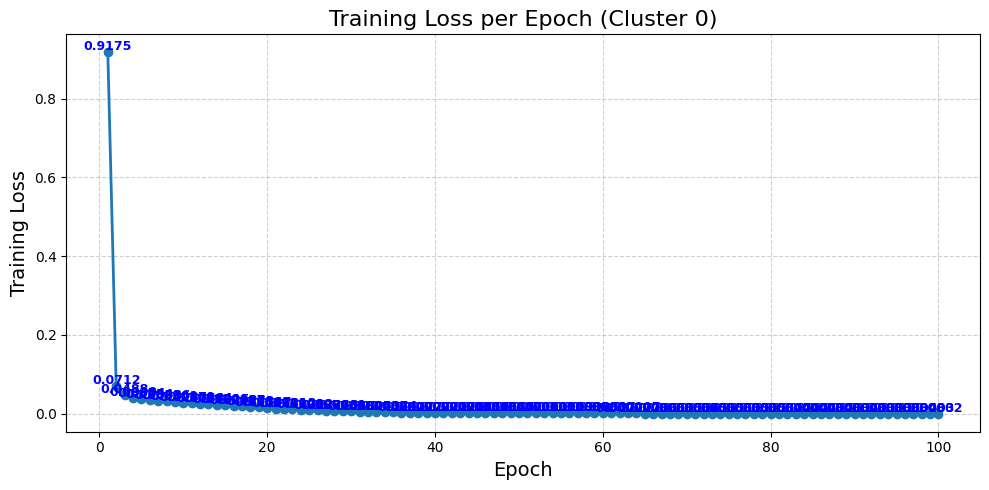

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\models_\model0000


In [15]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [16]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [17]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (38, 2535, 2)
Example prediction: [[1.0000000e+00 2.1792776e-19]
 [1.0000000e+00 3.1441409e-14]
 [1.0000000e+00 6.3128806e-19]
 ...
 [1.0000000e+00 3.2715631e-16]
 [1.0000000e+00 2.1429549e-12]
 [2.4956647e-14 1.0000000e+00]]


In [18]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [25]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [20]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: CC1CN=C(S1)N(C(=S)NCC=C)C2=CC(C)=CC=N2 | True: CC1CN=C(S1)N(C(=S)NCC=C)C2=CC(C)=CC=N2 | Tanimoto: 1.000
[1] Pred: CC(C)CC1(C)NN(C(=S)N1)C2=CC=C(C)C=C2 | True: CC(C)CC1(C)NN(C(=S)N1)C2=CC=C(C)C=C2 | Tanimoto: 1.000
[2] Pred: CN1CCN(CC1)C2=NC(C)=NC=3N(C(=S)SC2=3)C4=CC=CC=C4 | True: CN1CCN(CC1)C2=NC(C)=NC=3N(C(=S)SC2=3)C4=CC=CC=C4 | Tanimoto: 1.000
[3] Pred: CSC1=NC(C)=NC(N)=C1C#N | True: CSC1=NC(C)=NC(N)=C1C#N | Tanimoto: 1.000
[4] Pred: CC(C)SC1=NN=C2C(=N1)N(CC=C)C3=CC=CC=C23 | True: CC(C)SC1=NN=C2C(=N1)N(CC=C)C3=CC=CC=C23 | Tanimoto: 1.000
[5] Pred: CC1=NN2C(NC(=S)C1)=CN=C2C3=CC=CC=C3 | True: CC1=NN2C(NC(=S)C1)=CN=C2C3=CC=CC=C3 | Tanimoto: 1.000
[6] Pred: CC=1C=C(C)N2N=C(SCC#N)N=C2N=1 | True: CC=1C=C(C)N2N=C(SCC#N)N=C2N=1 | Tanimoto: 1.000
[7] Pred: CCSC1=NN2C(C)=CC(C)=NC2=N1 | True: CCSC1=NN2C(C)=CC(C)=NC2=N1 | Tanimoto: 1.000
[8] Pred: CSC1=NN=C2N(C=NN12)N3C=CC=C3 | True: CSC1=NN=C2N(C=NN12)N3C=CC=C3 | Tanimoto: 1.000
[9] Pred: CCN1CCN(CC1)C2=NC=NC=3N(C(=S)SC2=3)C4=CC=CC=C4

Epoch 1/100 - Loss: 0.179201
Epoch 2/100 - Loss: 0.039058
Epoch 3/100 - Loss: 0.035661
Epoch 4/100 - Loss: 0.033062
Epoch 5/100 - Loss: 0.031261
Epoch 6/100 - Loss: 0.029548
Epoch 7/100 - Loss: 0.028480
Epoch 8/100 - Loss: 0.027156
Epoch 9/100 - Loss: 0.025808
Epoch 10/100 - Loss: 0.024493
Epoch 11/100 - Loss: 0.023091
Epoch 12/100 - Loss: 0.021937
Epoch 13/100 - Loss: 0.020721
Epoch 14/100 - Loss: 0.019347
Epoch 15/100 - Loss: 0.018320
Epoch 16/100 - Loss: 0.017113
Epoch 17/100 - Loss: 0.016061
Epoch 18/100 - Loss: 0.015281
Epoch 19/100 - Loss: 0.014183
Epoch 20/100 - Loss: 0.013357
Epoch 21/100 - Loss: 0.012380
Epoch 22/100 - Loss: 0.011586
Epoch 23/100 - Loss: 0.010912
Epoch 24/100 - Loss: 0.010357
Epoch 25/100 - Loss: 0.009681
Epoch 26/100 - Loss: 0.009252
Epoch 27/100 - Loss: 0.008854
Epoch 28/100 - Loss: 0.008181
Epoch 29/100 - Loss: 0.007818
Epoch 30/100 - Loss: 0.007368
Epoch 31/100 - Loss: 0.006979
Epoch 32/100 - Loss: 0.006519
Epoch 33/100 - Loss: 0.006293
Epoch 34/100 - Loss

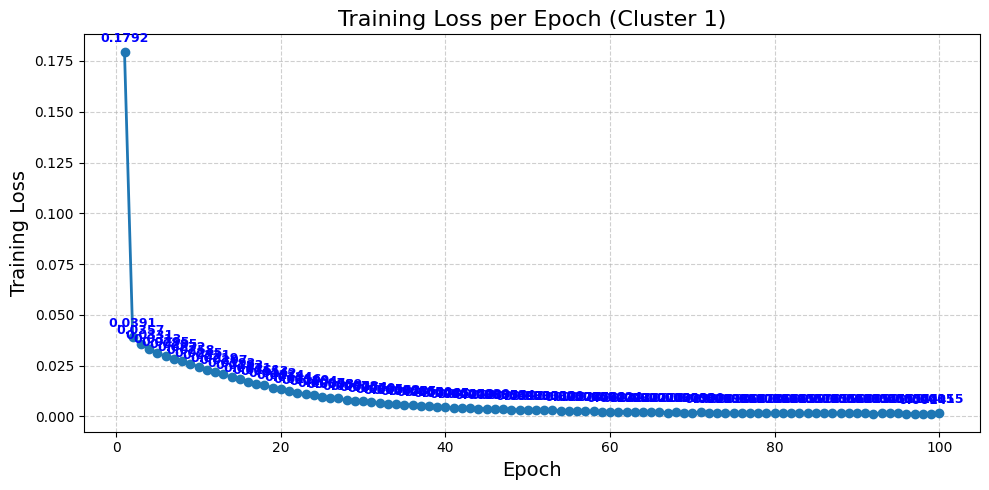

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with seed 123\models_\model1111


In [21]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [22]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (246, 2535, 2)
Example prediction: [[1.0000000e+00 1.2786799e-12]
 [1.0000000e+00 4.8573256e-08]
 [1.0000000e+00 1.6700115e-08]
 ...
 [1.0000000e+00 4.2344570e-10]
 [1.0000000e+00 1.1119726e-09]
 [7.4067017e-13 1.0000000e+00]]
[0] Pred: C1NCC(S1)C2=CC=CC=C2 | True: C1NCC(S1)C2=CC=CC=C2 | Tanimoto: 1.000
[1] Pred: CN(C)C(C)C=CSC | True: CNCCCC=1SC(NC2=CC=CC=C2)=NN=1 | Tanimoto: 0.045
[2] Pred: CN(N)CCC | True: CNCCCCCC=1SC(SC)=NN=1 | Tanimoto: 0.054
[3] Pred: CC(=NNC(N1)=S)C=CC#CC2=CC=C3C=CC1OC23 | True: NC(=S)N\N=C/C1=C2C=CC=CC2=CC3=CC=CC=C13 | Tanimoto: 0.128
[4] Pred: C=NC=C | True: CCN(CC)C(=S)NC=1SC=CN=1 | Tanimoto: 0.013
[5] Pred: NC=NCC=SN | True: NC=1SC(N)=NN=1 | Tanimoto: 0.018
[6] Pred: CN(C)CCN(CC=1SC=CC=1)C2=CC=CC=N2 | True: CN(C)CCN(CC1=CSC=C1)C2=CC=CC=N2 | Tanimoto: 0.638
[7] Pred: NC(=N)SN | True: S=C(NC1=CC=CC=C1)NC=2SC=CN=2 | Tanimoto: 0.017
[8] Pred: CN(C)CCC1CNC=CC=CC=C1N | True: CN(C)CCCN1C(S)=NN=C1C2=CC(C)=NN2C | Tanimoto: 0.129
[9] Pred: C(C)CSC

---------------------------------------------------

Epoch 1/100 - Loss: 0.704915
Epoch 2/100 - Loss: 0.063203
Epoch 3/100 - Loss: 0.040868
Epoch 4/100 - Loss: 0.036019
Epoch 5/100 - Loss: 0.033939
Epoch 6/100 - Loss: 0.032520
Epoch 7/100 - Loss: 0.031041
Epoch 8/100 - Loss: 0.029883
Epoch 9/100 - Loss: 0.028536
Epoch 10/100 - Loss: 0.027120
Epoch 11/100 - Loss: 0.025649
Epoch 12/100 - Loss: 0.024168
Epoch 13/100 - Loss: 0.022554
Epoch 14/100 - Loss: 0.021071
Epoch 15/100 - Loss: 0.019604
Epoch 16/100 - Loss: 0.018128
Epoch 17/100 - Loss: 0.016675
Epoch 18/100 - Loss: 0.015623
Epoch 19/100 - Loss: 0.014351
Epoch 20/100 - Loss: 0.013417
Epoch 21/100 - Loss: 0.012387
Epoch 22/100 - Loss: 0.011512
Epoch 23/100 - Loss: 0.010673
Epoch 24/100 - Loss: 0.009779
Epoch 25/100 - Loss: 0.008826
Epoch 26/100 - Loss: 0.008245
Epoch 27/100 - Loss: 0.007265
Epoch 28/100 - Loss: 0.006736
Epoch 29/100 - Loss: 0.006023
Epoch 30/100 - Loss: 0.005718
Epoch 31/100 - Loss: 0.005185
Epoch 32/100 - Loss: 0.004725
Epoch 33/100 - Loss: 0.004445
Epoch 34/100 - Loss

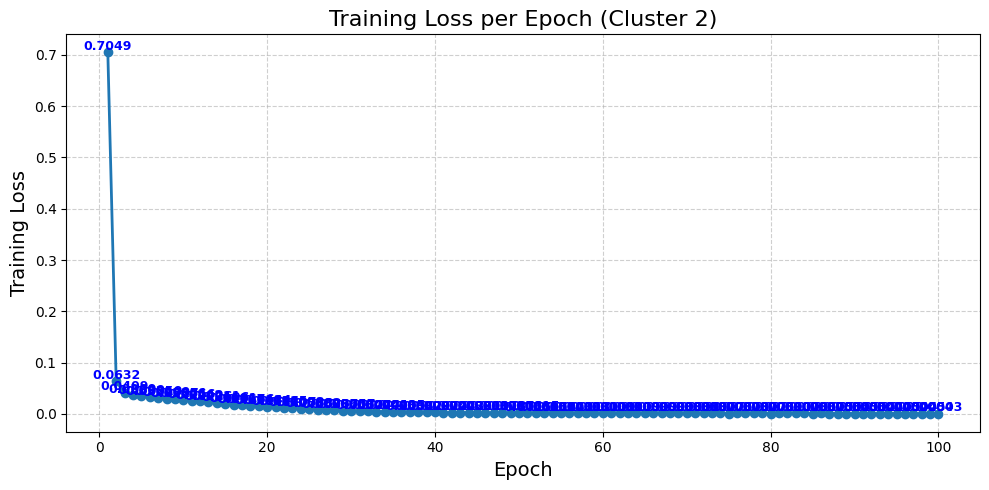

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with seed 123\models_\model2222


In [23]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [24]:
# === Load cluster 2 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2717_CHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 2
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_2
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])

evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (41, 2535, 2)
Example prediction: [[1.0000000e+00 2.4159825e-09]
 [9.9999988e-01 7.1895130e-08]
 [9.9999881e-01 1.1420680e-06]
 ...
 [9.9999964e-01 3.1736499e-07]
 [9.9999964e-01 3.1412799e-07]
 [1.2301824e-06 9.9999881e-01]]
[0] Pred: CCS1C=C(C=CC1)CNCSC(C)C=C | True: N(N=CC=1SC=CC=1SC2=CSC=C2)C3=CC=CC=C3 | Tanimoto: 0.080
[1] Pred: CC1=CC=C(SC2=NNC(=NC3=CC=CC=C23)C4=CC=CC=C4)C=C1 | True: CC1=CC=C(SC2=NNC(=NC3=CC=CC=C23)C4=CC=CC=C4)C=C1 | Tanimoto: 1.000
[2] Pred: CC1=CC=CC(C)=C1NC(=S)N\N=C(/C)C2=CC=CC=N2 | True: CC1=CC=CC(C)=C1NC(=S)N\N=C(/C)C2=CC=CC=N2 | Tanimoto: 1.000
[3] Pred: CC1=CC=CC(NC(=S)N\N=C(/C)C2=CC=CC=N2)=C1 | True: CC1=CC=CC(NC(=S)N\N=C(/C)C2=CC=CC=N2)=C1 | Tanimoto: 1.000
[4] Pred: CC1=CC=C(NC(=S)N\N=C(/C)C2=CC=CC=N2)C(C)=C1 | True: CC1=CC=C(NC(=S)N\N=C(/C)C2=CC=CC=N2)C(C)=C1 | Tanimoto: 1.000
[5] Pred: C\C(=N\NC(=S)N1CCN(CC1)C2CCCCCC2)C3=CC=CC=N3 | True: C\C(=N\NC(=S)N1CCN(CC1)C2CCCCCC2)C3=CC=CC=N3 | Tanimoto: 1.000
[6] Pred: S=C(NN=CCC1=CC=CC=N1)C